In [20]:
import numpy as np
import numpy.linalg as la
import matplotlib.pyplot as plt

# Lesson 10: SVD And Applications

Recall the Singular Value Decomposition (SVD) for a non-square matrix ${\bf A}$ with dimensions $m \times n$:

$$ {\bf A} = {\bf U\Sigma V}^{T} = \begin{bmatrix}\vert & & \vert & & \vert \\ \vert & & \vert & & \vert \\ {\bf u}_1 & \cdots & {\bf u}_n & \cdots & {\bf u}_m\\ \vert & & \vert & & \vert \\\vert & & \vert & & \vert \end{bmatrix} \begin{bmatrix} \sigma_1 & & \\ & \ddots & \\ & & \sigma_n \\ &  \vdots &  \\ -& 0& -\end{bmatrix} \begin{bmatrix} - & {\bf v}_1^T & - \\ & \vdots & \\ - & {\bf v}_n^T & - \end{bmatrix} $$

where the example above illustrates a matrix where $m > n$. ${\bf U}$ is an $m \times m$ orthogonal matrix whose columns are the left singular vectors, ${\bf \Sigma}$ is an $m\times n$ diagonal matrix whose entries are the singular values, and ${\bf V}$ is an $n \times n$ orthogonal matrix whose columns are the right singular vectors.

We will be using the built-in SVD function [numpy.linalg.svd](https://numpy.org/doc/stable/reference/generated/numpy.linalg.svd.html):
```python
U, S, Vt = la.svd(A)
```
Note that the matrix containing the right singular vectors is returned as transpose format so that the rows are the right singular vectors.

Compute the SVD of the matrix A:

In [21]:
A = np.array([[1, 2],
              [3, 4],
              [5, 6]])

In [22]:
U, S, Vt = la.svd(A)

Check the shape (dimensions) of the matrices:

In [23]:
print(U.shape)
print(S.shape)
print(Vt.shape)

(3, 3)
(2,)
(2, 2)


And take a look at each one of the matrices:

In [24]:
print(U)
print(S)
print(Vt)

[[-0.2298477   0.88346102  0.40824829]
 [-0.52474482  0.24078249 -0.81649658]
 [-0.81964194 -0.40189603  0.40824829]]
[9.52551809 0.51430058]
[[-0.61962948 -0.78489445]
 [-0.78489445  0.61962948]]


Note that the diagonal matrix ${\bf \Sigma}$ is returned as a 1d numpy array, including only the $n$ diagonal entries (instead of a matrix with shape $m \times n$). The shape of the 1d numpy array is `(k,)`, where `k = min(m,n)`.

In the above example, ${\bf \Sigma}$ has shape $(3,2)$, however `numpy.linalg.svd` returns a 1d array of shape $(2,)$.

You can reconstruct the matrix ${\bf \Sigma}$ if needed:

In [25]:
m = 3
n = 2
Sigma = np.zeros((m,n))
np.fill_diagonal(Sigma, S)
Sigma

array([[9.52551809, 0.        ],
       [0.        , 0.51430058],
       [0.        , 0.        ]])

And you can use SVD to reconstruct the matrix:

In [26]:
U @ Sigma @ Vt

array([[1., 2.],
       [3., 4.],
       [5., 6.]])

When dealing with non-square matrices, it is often better to use the SVD in its reduced form:

$$ {\bf A} = {\bf U_R\Sigma_R V}^{T} =  \begin{bmatrix}\vert & & \vert \\  \vert & & \vert \\ {\bf u}_1 & \cdots & {\bf u}_n \\ \vert & & \vert \\ \vert & & \vert \end{bmatrix} \begin{bmatrix} \sigma_1 & & \\ & \ddots & \\ & & \sigma_n \end{bmatrix} \begin{bmatrix} - & {\bf v}_1^T & - \\ & \vdots & \\ - & {\bf v}_n^T & - \end{bmatrix} $$

where ${\bf U}_R$ is an $m \times n$ matrix, and ${\bf \Sigma}_R$ is an $n \times n$ diagonal matrix.

To accomplish this using the SVD built-in function, we use the argument `full_matrices=False`.

In [27]:
UR, SR, VRt = la.svd(A, full_matrices=False)
print(UR.shape)
print(SR.shape)
print(VRt.shape)

(3, 2)
(2,)
(2, 2)


Reconstruct the matrix A using the reduced SVD. Since ${\bf \Sigma}_R$ is square, we may use [numpy.diag](https://numpy.org/doc/stable/reference/generated/numpy.diag.html) to reconstruct it from the output of the SVD function.

In [28]:
UR @ np.diag(SR) @ VRt

array([[1., 2.],
       [3., 4.],
       [5., 6.]])

## 1) Image Compression

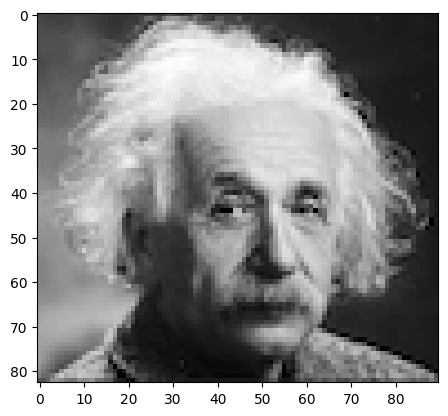

In [29]:
einstein = plt.imread("einstein.png")[:,:,0]
plt.imshow(einstein, cmap="gray")

Now that you know how to obtain the singular value decomposition of a matrix, let's try to better understand the meaning of each of the components. 

We will continue to use our notation where ${\bf u}_i$ corresponds to the $i^{th}$ column of ${\bf U}$, and ${\bf v}_i^T$ the $i^{th}$ row of ${\bf V}^T$.

**Check your answers:**

Compute the reduced SVD of the Einstein image above.

Store the reduced decomposition in the usual way: `U_einstein` is a 2d array whose columns are the left singular vectors, `S_einstein` is a 1d array whose entries are the singular values, and `Vt_einstein` is a 2d array whose rows are the right singular vectors.

In [30]:
#grade (enter your code in this cell - DO NOT DELETE THIS LINE) 

U_einstein, S_einstein, Vt_einstein = la.svd(einstein, full_matrices=False)

The SVD of a matrix can also be written as:

$${\bf A} = {\bf U\Sigma V}^{T}  = \sum_{i=1}^k \sigma_i  {\bf u}_i {\bf v}_i^T $$

We will plot the image obtained from the computation $ \sigma_i {\bf u}_i  {\bf v}_i^T$ for a given value of $i$.

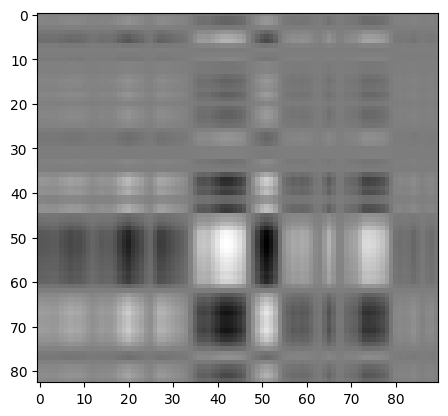

In [31]:
i = 4
plt.figure()
plt.imshow(np.outer(U_einstein[:,i], Vt_einstein[i]) * S_einstein[i], cmap="gray")

Does it look like anything? Try to use different value of $i$ to plot the image using the code provided above. **Discuss briefly with your group** what you think would happen when we add these $i$ "layers" together.

**Check your answers:**

Write a code snippet that adds the first 5 images generated from the outer products $\sigma_i {\bf u}_i  {\bf v}_i^T$ for $i \in \{0 \ldots 4\}$. 

Store this image as the 2d array `M`.

*Hint: Recall that a column vector multiplied by a row vector results in a matrix. When each ${\bf u}_i$ and ${\bf v}_i^T$ is stored as a 1d array, use [numpy.outer](https://numpy.org/doc/stable/reference/generated/numpy.outer.html) to enact this outer product.*

In [38]:
#grade (enter your code in this cell - DO NOT DELETE THIS LINE) 
num_images = 4  # number of images to add

M = np.zeros_like(einstein, dtype=float)
for i in range(num_images):
    M += S_einstein[i] * np.outer(U_einstein[:, i], Vt_einstein[i])

Plot the image resulting from this summation using `plt.imshow(M, cmap="gray")`.

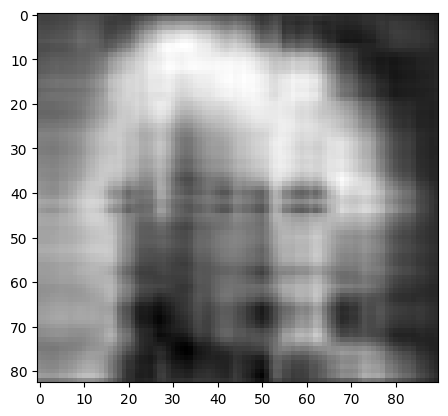

In [39]:
plt.imshow(M, cmap="gray")

We get an image that looks somewhat like our original starting image.  We can think of the SVD as breaking up our data into different "layers" or "parts" that get added together, and the $\sigma_i$ component determines how much of each component we add.  Here the matrix `M` is an approximation of the original matrix `einstein`.

<div class="alert alert-warning" role="alert">
    
**Answer this:** What is the rank of the approximated matrix that generates the image above? Think about the definition of matrix rank that you learned in class. You don't need to do any computation to get this result!
</div>

**Try this:**

Before moving on, try playing around with different values of `num_images` to see what sort of results you get.  Does the quality of the image scale linearly with the values of `num_images`? How does it change the rank of the matrix? Copy paste your code for generating `M` from above and try to change the value of `num_images` to see different results.

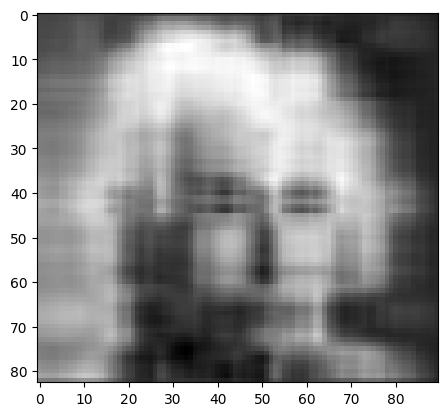

In [40]:
num_images = 5  # try some different values of it!
# paste your code for generating M here
M = np.zeros_like(einstein, dtype=float)
for i in range(num_images):
  M += np.outer(U_einstein[:,i],Vt_einstein[i]) * S_einstein[i]
# plot the image
plt.imshow(M, cmap="gray")

The contribution of each "layer" is given by its respective singular value ($\sigma_i$), the entries of ${\bf \Sigma}$. Numpy's SVD function will automatically order the singular values in descending order for us.  Because of this, if we plot the singular values we can see that the first values give a much larger contribution in the form of broad details, and then later values give smaller, finer contributions to the image.

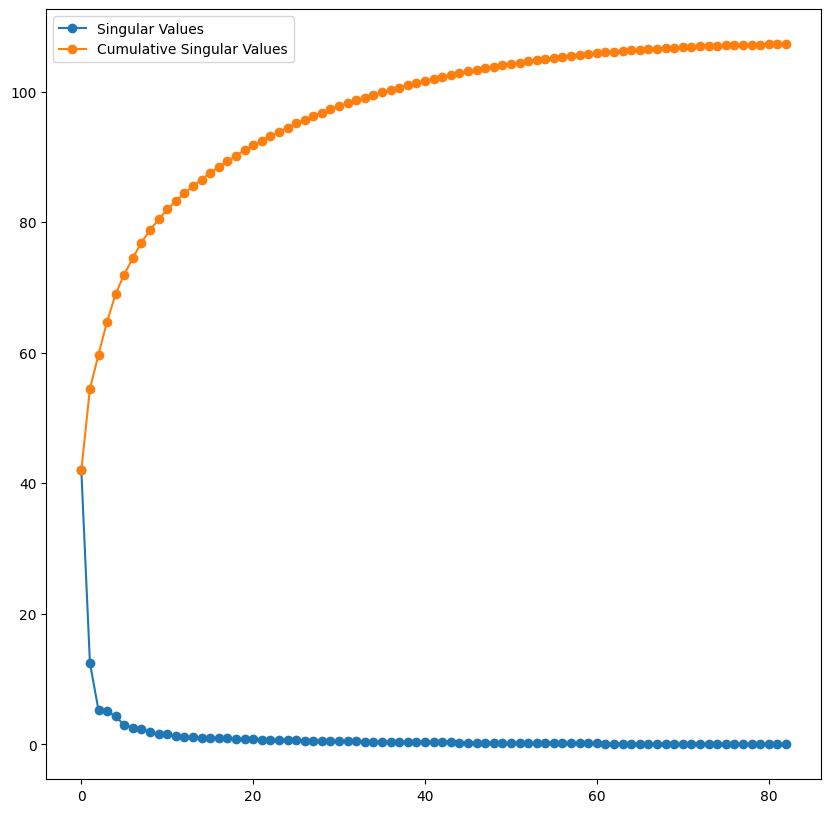

In [41]:
plt.figure(figsize=(10,10))
plt.plot(S_einstein, 'o-', label="Singular Values")
plt.plot(np.cumsum(S_einstein), 'o-', label="Cumulative Singular Values")
plt.legend()

**Check your answers:**

Intuitively, what should happen if we add every layer together?  Write a loop to add every layer together, and then plot the resulting image.  The number of "layers" or "components" to add will be given by the number of singular values ($\sigma$).

Store your result in variable `M_all`.

In [45]:
#grade (enter your code in this cell - DO NOT DELETE THIS LINE) 


M_all = np.zeros_like(einstein, dtype=float)
for i in range(len(S_einstein)):
    M_all += S_einstein[i] * np.outer(U_einstein[:, i], Vt_einstein[i])
S_einstein.shape

(83,)

Now you can plot the image:

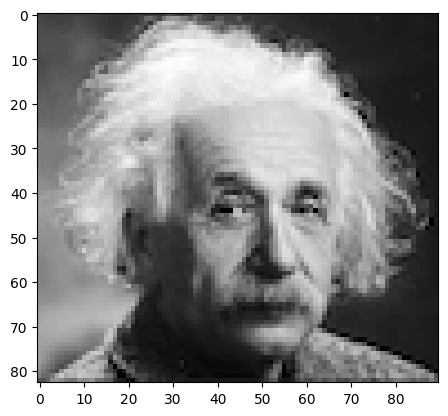

In [46]:
plt.imshow(M_all, cmap="gray")

In [47]:
import numpy as np
import numpy.linalg as la
import matplotlib.pyplot as plt

plt.figure()
plt.imshow(altgeld, cmap='gray')

# Compute the SVD and compress the image

U, S, Vt = la.svd(altgeld, full_matrices=False)

num_layers = -1
for i in range(len(S)):
  if S[0:i].sum() / S.sum() >= 0.59 and num_layers == -1:
    num_layers = i - 1 # Starred for python quiz: remember to minus 1

N = np.zeros_like(altgeld, dtype=float)
for i in range(num_layers+1): # Starred for python quiz: and then add the 1 back
  N += S[i] * np.outer(U[:,i], Vt[i])
  
altgeld_compressed = N # Change this!

# Plot the final image

plt.figure()
plt.imshow(altgeld_compressed, cmap='gray')

NameError: name 'altgeld' is not defined

<Figure size 640x480 with 0 Axes>

In [48]:
import numpy as np
import numpy.linalg as la
import matplotlib.pyplot as plt
from matplotlib import cm

U, S, Vt = la.svd(measurement)
differences = []
for k in range(len(S)):
  B_k = np.zeros_like(measurement)
  for i in range(k+1): 
    B_k += S[i] * np.outer(U[:,i], Vt[i])
  differences.append(
    la.norm(B_k - exact_data)
  )

differences = np.array(differences)
min_d = min(differences)
for i, dif in enumerate(differences):
  if dif==min_d:
    num_layers = i 

denoised_data = np.zeros_like(measurement) # Change this
for i in range(num_layers + 1): 
  denoised_data += S[i] * np.outer(U[:,i], Vt[i])

# Plot the data
display_plot(measurement)
display_plot(denoised_data)
display_plot(exact_data)

#uncomment to plot differences
plt.figure()
plt.plot(differences, 'r.')

NameError: name 'measurement' is not defined



In this question, you will analyze the relationships between variables using SVD.


You will be provided with an array A where each row represents an article published on mashable.com and each column represents a feature or observation variable relating to the article, such as the number of images and the number of keywords in the article.



Your goal is to search for linear relationships between the features. For example, if the columns of A are A1,…Am, a linear relationship between A1, A2, and A3 might look something like A1=5⁢A2−2.7⋅A3. In other words, there is some linear combination x1⁢A1+x2⁢A2+⋯+xn⁢An=0, i.e. A⁢x=0. Then AT⁢A⁢x=AT⁢0=0 and so one of the eigenvalues of AT⁢A is 0. Since the singular values of A are the square roots of the eigenvalues of AT⁢A, one of the singular values is 0.


Note however that this relationship will only hold if the variables are exactly correlated which never happens in the real world.

To examine how to get some information about your data when there is some fuzziness, we can look at the singular value decomposition of A=U⁢Σ⁢VT. To account for fuzziness, let us assume that instead of A⁢x=0, we have that ||⁢A⁢x⁢||=ϵ where ϵ is very small compared with ||⁢x⁢||. Since U and V are both orthogonal matrices, for any vectors, y and z, we have ||⁢U⁢y⁢||=||⁢y⁢|| and ||⁢VT⁢z⁢||=||⁢z⁢||. Therefore, ||⁢A⁢x⁢||=ϵ implies ||⁢U⁢Σ⁢VT⁢x⁢||=ϵ and so ||⁢Σ⁢VT⁢x⁢||=ϵ. Letting y=VT⁢x, we know that ||⁢y⁢||=||⁢VT⁢x⁢||=||⁢x⁢||, and since ||⁢Σ⁢y⁢||=ϵ<<||⁢y⁢||, we know that at least one of the singular values of A is small.



So we've now seen that if A has some features which depend on each other, then at least one of its singular values are small, but how can we determine which of the features are the dependent ones?


Let e1,e2,…,en be the standard basis for Rn. Consider vi=V⁢ei, which is equivalent to the i-th column of V. Then 
||⁢A⁢vi⁢||=||⁢U⁢Σ⁢VT⁢vi⁢||=||⁢Σ⁢VT⁢vi⁢||=||⁢Σ⁢VT⁢V⁢ei⁢||=||⁢Σ⁢ei⁢||=σi.
Thus, if you know the i-th singular value is small, you know that vi will give you a combination of features with a near-linear relationship.


So if you know the i-th singular value is small, you know that vi will give you a combination of features which is very small. To look at which features are linked, we can look at the values of vi. In an exact world with no fuzziness, we could just look at the features which are non-zero in vi. However, because we do live in the real world, we must instead look at the features which are outside some range of 0.

In this question, you will find: 

A list whose entries are the singular values σi of A which are less than or equal to 0.05. Save this as small_sig.
A list whose entries are the individual columns vi of V (not VT) which correspond to the singular values σi in small_sig. Save this as small_vecs
A list related_columns whose entries are lists themselves. Each list in related_columns should correspond to one of the vectors vi in small_vecs. Determine which values of vi are greater in absolute value than 0.1. Add the corresponding column name from column_names to the list in related_columns corresponding to vi. Each of these lists corresponds to a group of columns which have a near-linear relationship.

Once you have completed this, print the lists in related_columns and see if these results are surprising.



The setup code gives the following variables:

Name	Type	Description
A	numpy array	1000x60 array where each row represents the data associated to an individual Mashable article
column_names	list of strings	a list of the names for each column in A

Your code snippet should define the following variables:


Name
Type
Description

small_sig
list of floats
A list of the singular values of A which are less than or equal to 0.05

small_vecs
list of 1D numpy arrays
A list of the columns of V corresponding to the values in small_sig


related_columns
list of lists of strings
A list whose elements are lists containing the names of columns which share a near-linear relationship


## 2) SVD Least Squares

Because SVD allows us to decompose matrices of arbitrary size and rank, we are also able to use it in least squares applications.

Recall the least squares problem: find the vector ${\bf x}$ which minimizes $\left\lVert {\bf Ax} - \bf{y} \right\rVert^2$. Using the SVD component summation for ${\bf A}$ and since ${\bf U}$ is orthogonal, we can express the squares expression as:

$$
\left\lVert {\bf Ax} - \bf{y} \right\rVert^2 =
\sum_{i=1}^r \left(\sigma_i z_i - u^T_i y\right)^2
$$

where ${\bf z} = {\bf V}^T{\bf x}$, each $u^T_i$ is the $i^{th}$ row of ${\bf U}^T$ (i.e. the $i^{th}$ column of ${\bf U}$ as a row vector), and $r$ is the rank of ${\bf A}$ (the count of nonzero singular values).  By rearranging and minimizing the expression above over ${\bf x}$ (and thus over ${\bf z}$), we obtain the analytical solution for ${\bf z}$:
$$z_i = \frac{u^T_iy}{\sigma_i}$$ 
with non-zero $\sigma_i$. When $\sigma_i = 0$, ${\bf A}$ is rank-deficient and we set $z_i = 0$ so that the corresponding component does not contribute to the least squares solution.

Here we have a noisy dataset to which we would like to fit a curve. We will try using the above analysis to solve this least squares problem.

Text(0, 0.5, 'y')

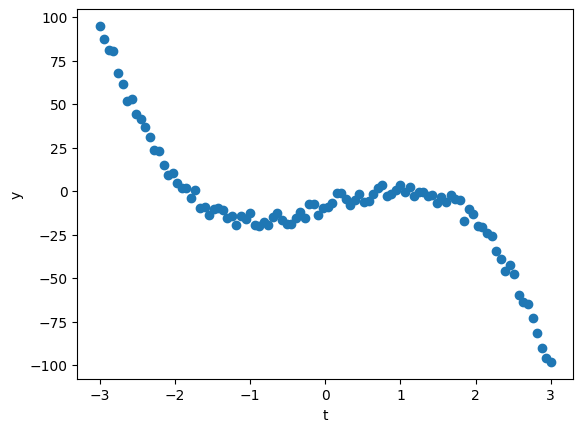

In [50]:
n = 100
t = np.linspace(-3, 3, n)
y = np.loadtxt('lstsq.txt')
plt.plot(t, y, 'o')
plt.xlabel('t')
plt.ylabel('y')

Fit the data using the following polynomial with degree 3:

$$ y = 1 x_0 + t x_1 + t^2 x_2 + t^3 x_3 $$

**Check your answers:**

Create the design matrix ${\bf A}$ to fit the cubic polynomial above. Store ${\bf A}$ aa a 2d array `A`.

*Hint: Recall that the $i^{th}$ column of the design matrix contains the coefficient multiplying $x_i$.*

In [51]:
#grade (enter your code in this cell - DO NOT DELETE THIS LINE) 


A = np.column_stack([np.ones_like(t), t, t**2, t**3])
A

array([[ 1.00000000e+00, -3.00000000e+00,  9.00000000e+00,
        -2.70000000e+01],
       [ 1.00000000e+00, -2.93939394e+00,  8.64003673e+00,
        -2.53964716e+01],
       [ 1.00000000e+00, -2.87878788e+00,  8.28741965e+00,
        -2.38577232e+01],
       [ 1.00000000e+00, -2.81818182e+00,  7.94214876e+00,
        -2.23824192e+01],
       [ 1.00000000e+00, -2.75757576e+00,  7.60422406e+00,
        -2.09692239e+01],
       [ 1.00000000e+00, -2.69696970e+00,  7.27364555e+00,
        -1.96168016e+01],
       [ 1.00000000e+00, -2.63636364e+00,  6.95041322e+00,
        -1.83238167e+01],
       [ 1.00000000e+00, -2.57575758e+00,  6.63452709e+00,
        -1.70889334e+01],
       [ 1.00000000e+00, -2.51515152e+00,  6.32598714e+00,
        -1.59108162e+01],
       [ 1.00000000e+00, -2.45454545e+00,  6.02479339e+00,
        -1.47881292e+01],
       [ 1.00000000e+00, -2.39393939e+00,  5.73094582e+00,
        -1.37195370e+01],
       [ 1.00000000e+00, -2.33333333e+00,  5.44444444e+00,
      

Compute the reduced SVD of ${\bf A}$:

In [52]:
U_lsq, S_lsq, Vt_lsq = la.svd(A, full_matrices=False)

**Check your answers:**

Compute the vector ${\bf z}$ using the equation from above:
$$z_i = \frac{u^T_i y}{\sigma_i} .$$
Store ${\bf z}$ as a 1d array `z`.

*Hint: How do we determine the desired length of ${\bf z}$?*

*Hint: Recall that a row vector multiplied by a column vector results in a scalar. When $y$ and every $u^T_i$ are stored as 1d arrays, use [numpy.dot](https://numpy.org/doc/stable/reference/generated/numpy.dot.html) to enact this dot/inner product. Usual matrix multiplication with the `@` symbol also works here.*

In [55]:
#grade (enter your code in this cell - DO NOT DELETE THIS LINE) 

z = np.array([np.dot(U_lsq[:, i], y) / S_lsq[i] for i in range(len(S_lsq))])

**Check your answers:**

Now that we have the vector ${\bf z}$, compute the least squares solution ${\bf x}$ using the replacement equation from above: $${\bf z}={\bf V}^T{\bf x} . $$

Store ${\bf x}$ as a 1d array `x`.

*Hint: Try to avoid calling `numpy.linalg.inv` or `numpy.linalg.solve`. Since ${\bf V}^T$ is orthogonal, how can we efficiently compute its inverse?*

In [54]:
#grade (enter your code in this cell - DO NOT DELETE THIS LINE) 


x = Vt_lsq.T @ z

Here we plot your polynomial to confirm it fits the original data.

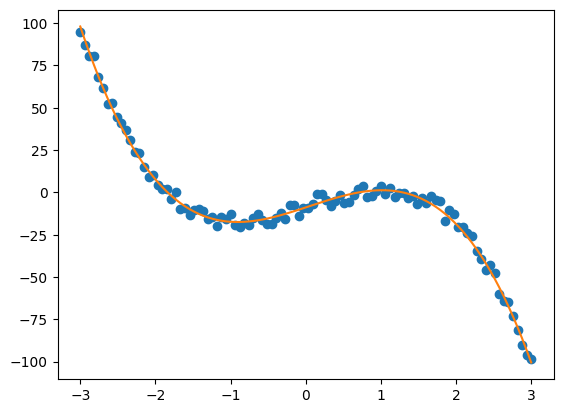

In [27]:
plt.plot(t, y, 'o')
plt.plot(t, A@x)

We can aggregate this procedure with ${\bf z}$ into a convenient matrix operator: the *pseudoinverse* of ${\bf A}$. We can rewrite the above in matrix form to derive a simple expression for the least squares solution ${\bf x}$ using the reduced SVD for ${\bf A}$:

$$z_i = \frac{u^T_iy}{\sigma_i} \implies {\bf z} = {\bf \Sigma}^{+} {\bf U}^T {\bf y} \implies {\bf x} = {\bf V \Sigma}^{+} {\bf U}^T {\bf y} \implies {\bf x} = {\bf A}^{+} {\bf y} . $$

Here, ${\bf A}^{+}$ is the *pseudoinverse* of ${\bf A}$. This always exists, regardless of the shape or rank of ${\bf A}$ (whereas ${\bf A}$ only has an inverse ${\bf A}^{-1}$ if it is square and full-rank). As indicated above, we have:

$$ {\bf A}^{+} = {\bf V\bf\Sigma}^{+}{\bf U}^T .$$

For the pseudoinverse ${\bf \Sigma}^+$, where ${\bf \Sigma}$ is a diagonal matrix, we define:
$$
\left( {\bf \Sigma}^{+} \right)_i = \begin{cases} 0 & \sigma_i = 0 \\ \frac{1}{\sigma_i} & \sigma_i \neq 0\end{cases}
$$
as we did above with the treatment of each $z_i$.

**Check your answers:**

Let's calculate the least squares solution above using the pseudoinverse of ${\bf A}$. You already have the reduced SVD of ${\bf A}$, so you now need to compute the pseudoinverse of the singular value matrix ${\bf \Sigma}$. 

Store ${\bf \Sigma}^+$ as a 2d array `S_pinv`.

*Hint: The function [numpy.diag](https://numpy.org/doc/stable/reference/generated/numpy.diag.html) easily constructs a square matrix from an array of elements composing the main diagonal.*

In [29]:
#grade (enter your code in this cell - DO NOT DELETE THIS LINE) 

S_pinv = np.diag(1 / S_lsq)

**Check your answers:**

Form the pseudoinverse ${\bf A}^+$ of ${\bf A}$ using the definition ${\bf A}^+ = {\bf V\Sigma}^+{\bf U}^T$.

Store ${\bf A}^+$ as a 2d array `A_pinv`.

In [30]:
#grade (enter your code in this cell - DO NOT DELETE THIS LINE) 


A_pinv = Vt_lsq.T @ S_pinv @ U_lsq.T

Now we may easily compute the least squares solution ${\bf x}$ using the equation ${\bf x} = {\bf A}^+{\bf y}$.

Plot the polynomial fit below; does this align with the earlier result?

(4, 100) (4,) (100, 4)


array([-8.90084321, 14.62746177,  0.85118499, -5.30274234])

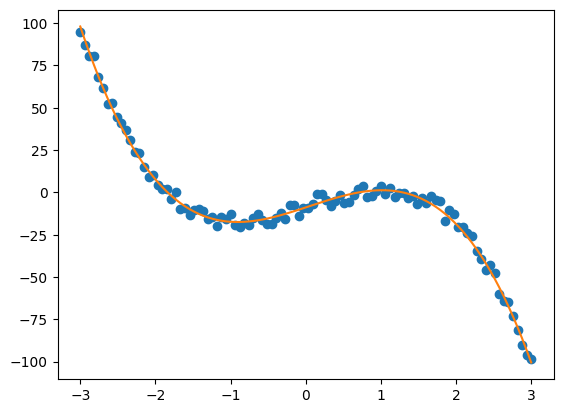

In [31]:
x_pinv = A_pinv @ y
print(A_pinv.shape, x_pinv.shape, A.shape)
plt.plot(t, y, 'o')
plt.plot(t, A@x_pinv)
x_pinv